# Model QUBO

**Quadratic Unconstrained Binary Optimization (QUBO)** to model do rozwiązywania problemów optymalizacji kombinatorycznej. Jak sugeruje nazwa, dotyczy on modeli optymalizacyjnych (O), w których występują zależności kwadratowe (Q) między zmiennymi binarnymi (B), brak ograniczeń (U). Co zaskakujące, warunki QUBO spełnia duża klasa problemów, takich jak MAX-CUT, problem komiwojażera czy harmonogramowanie zadań.  

## Model QUBO - definicja
Dla danej symetrycznej macierzy $Q$, należy znaleźć binarny wektor $\bm{x}^*$, taki że:  

$$ \bm{x}^* = \arg \min_x \bm{x}Q\bm{x}^T = \sum_i \sum_j Q_{ij} x_i x_j$$  

Często przekształca się macierz $Q$ do formy górnotrójkątnej - dla wszystkich $i$, $j$, gdzie $j > i$, zastępuje się element powyżej przekątnej $Q_{ij}$ przez $Q_{ij} + Q_{ji}$. Następnie wszystkie elementy poniżej przekątnej $Q_{ji}$ dla $j < i$ zamienia się na 0.  

Warto zauważyć, że dla zmiennych binarnych zachodzi $x^2 = x$ ($0^2=0$, $1^2=1$). Pozwala to podzielić QUBO na część liniową znajdującą się na diagonali oraz część kwadratową:  

$$ \bm{x}Q\bm{x}^T =  \sum_i Q_{ii} x_i + \sum_{i \neq j} Q_{ij} x_i x_j$$

## Rozwiązywanie QUBO - przykład

Podążając za przykładem spróbujemy lepiej zrozumieć, w jaki sposób można przekształcić problemy w formę QUBO.
Na początek rozważmy następujący problem optymalizacyjny - chcemy zminimalizować wartość wyrażenia:
$$
y = -5x_1 -3x_2 -8x_3 - 6x_4 + 4x_1x_2 + 8x_1x_3 + 2x_2x_3 + 10x_3x_4
$$

Obserwacje:  
1. $y$ składa się z części liniowej $-5x_1 -3x_2 -8x_3 - 6x_4$ oraz części kwadratowej $4x_1x_2 + 8x_1x_3 + 2x_2x_3 + 10x_3x_4$.  

2. Ponieważ dla zmiennych binarnych $x_i = x_i^2$, w części liniowej można zastąpić każdą zmienną jej kwadratem:  
$$  
-5x_1^2 -3x_2^2 -8x_3^2 - 6x_4^2  
$$  

co daje postać homogeniczną:
$$
y=-5x_1^2 -3x_2^2 -8x_3^2 - 6x_4^2+4x_1x_2 + 8x_1x_3 + 2x_2x_3 + 10x_3x_4
$$

3. Następnie możemy przekształcić model do następującej postaci macierzowej:  
$$  
y = [x_1 \, x_2 \, x_3 \, x_4] \begin{bmatrix}  
-5 & 4 & 8 & 0 \\  
0 & -3 & 2 & 0 \\  
0 & 0 & -8 & 10 \\  
0 & 0 & 0 & -6  
\end{bmatrix}  
\begin{bmatrix}  
x_1 \\  
x_2 \\  
x_3 \\  
x_4  
\end{bmatrix}  
$$  

lub krócej:  
$$  
y = \arg \min_x \bm{x}Q\bm{x}^T  
$$  
Należy zauważyć, że stosujemy tu konwencję zachowania $Q$ jako macierzy górnotrójkątnej.  

4. Poza wymogiem binarności zmiennych decyzyjnych, QUBO jest modelem nieograniczonym, gdzie wszystkie dane problemu są zawarte w macierzy $Q$. Fakt ten sprawia, że model QUBO jest atrakcyjną formą dla wielu problemów optymalizacyjnych.  

In [1]:
# Metota naiwnego wyczerpującego przeszukiwania

import numpy as np
from itertools import product
from math import inf
from copy import deepcopy

Q = np.array([[-5, 4, 8, 0], [0, -3, 2, 0], [0, 0, -8, 10], [0, 0, 0, -6]])

solution = inf
for x in product([0, 1], repeat=4):
    x = np.array(x)
    new_solution = x @ Q @ x.T
    if new_solution < solution:
        solution = deepcopy(new_solution)
        solution_vector = deepcopy(x)

print("rozwiązanie:", end = " ")
for idx, i in enumerate(solution_vector):
    print(f"x_{idx + 1} = {i},", end = " ")
print(f"\ny_min = {solution}")

rozwiązanie: x_1 = 1, x_2 = 0, x_3 = 0, x_4 = 1, 
y_min = -11


# Podobieństwo między QUBO a modelem Isinga

Nie sposób nie zauważyć, że wyrażenia opisujące QUBO i model Isinga są bliźniaczo podobne

$$  
H(\textbf{s}) = \sum_{i < j} J_{ij} s_i s_j + \sum_i h_i s_i  
\quad \text{oraz} \quad \bm{x}Q\bm{x}^T =  \sum_{i \neq j} Q_{ij} x_i x_j +  \sum_i Q_{ii} x_i $$ 
gdzie zakładamy, że $\textbf{J}$ i $\textbf{Q}$ są macierzami górnotrójkątnymi, $i = 1, \ldots, N$, a różnicą są wartości $s_i = \pm 1$, $x_i\in\lbrace 0, 1\rbrace$ .  

W rzeczywistości rozwiązanie QUBO i znajdowanie stanów podstawowych modelu Isinga to równoważne problemy! Można je stosunkowo łatwo przekształcić między sobą za pomocą następującego podstawienia:

$$  
x_i = \frac{s_i + 1}{2}  
$$  
$$  
s_i = 2x_i - 1  
$$  

Podstawiając te zmienne do odpowiednich wzorów, otrzymujemy:

$$  
Q_{ij} = 4 J_{ij}  
$$  
$$  
Q_{ii} = 2h_i - 2\sum_{j \neq i} J_{ij}  
$$  

oraz

$$  
J_{ij} = \frac{1}{4} Q_{ij}  
$$  
$$  
h_{i} = \frac{1}{2}Q_{ii} + \frac{1}{4} \sum_{j \neq i} Q_{ij}  
$$  

Należy pamiętać, że transformacja generuje pewną dodatkową stałą, więc uzyskane wartości funkcji celu nie mogą być porównywane bezpośrednio.

## Zamiana pomiędzy modelami

Na szczęście istnieje wiele narzędzi pozwalających automatycznie przechodzic pomiędzy modelami

In [3]:
# Zamiana między modelami. 
import numpy as np
from dimod import BinaryQuadraticModel 


# zamiana modelu Isinga na QUBO
N = 15
h = {i: 0.5 for i in range(N)}
J = {(i, i+1): -1 for i in range(N-1)}

bqm = BinaryQuadraticModel(h, J, vartype="SPIN")

# warto pamiętać, że zamiana daje nam zarówno model w nowej formie jak i tzw. offset czyli stałą którą musimy brac pod uwagę przy zamienianiu modeli

QUBO, offset = bqm.to_qubo()

print(offset)

-21.5


## Przykład - zapisanie problemu MAX-CUT jako QUBO

Problem Max Cut jest jednym z najbardziej znanych problemów optymalizacji kombinatorycznej. Dla danego grafu nieskierowanego $G(V,E)$ ze zbiorem wierzchołków  $V$ oraz zbiorem krawędzi  $E$, problem Max Cut polega na podziale zbioru  $V$ na dwa podzbiory, $S$, $T$, $S \cup T = V$, tak aby liczba krawędzi łączących te podzbiory (tzw. przeciętych przez cięcie) była jak największa.





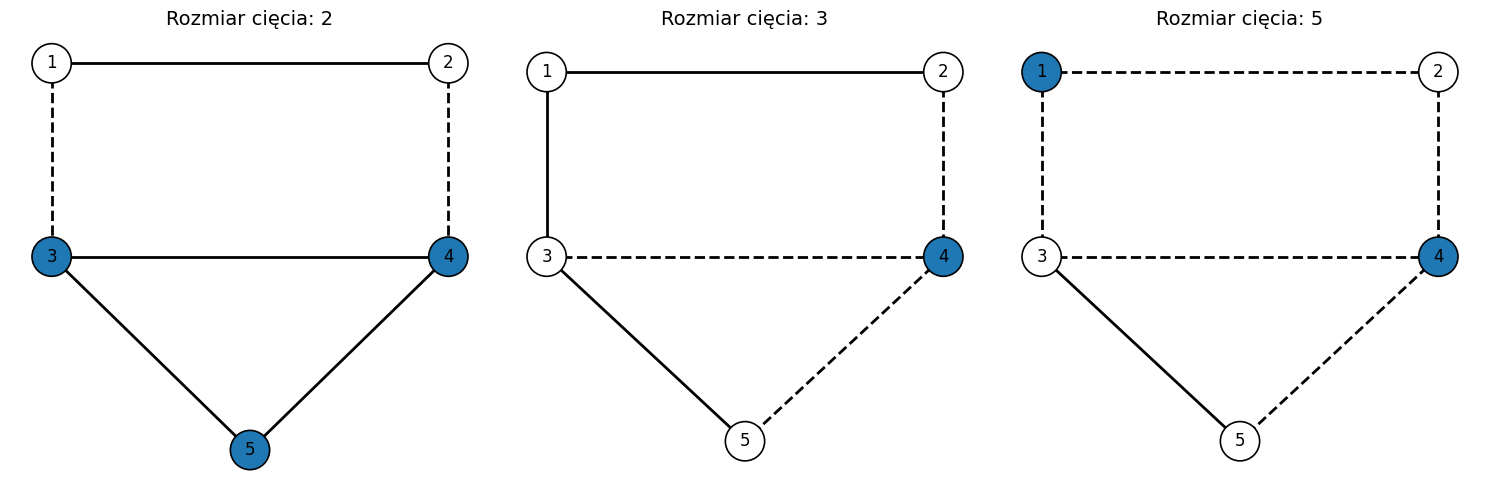

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# Utwórz graf
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([
    (1, 2),  # krawędź górna
    (1, 3),  # krawędź pionowa lewa
    (2, 4),  # krawędź pionowa prawa
    (3, 4),  # krawędź środkowa pozioma
    (3, 5),  # przekątna lewa
    (4, 5),  # przekątna prawa
])

# Stałe pozycje węzłów dla powtarzalnego układu
pos = {
    1: (0.0,  1.0),
    2: (1.0,  1.0),
    3: (0.0,  0.0),
    4: (1.0,  0.0),
    5: (0.5, -1.0),
}

# Definicja trzech rozcięć (zbiory S) wraz z tytułami
cuts = [
    ({3, 4, 5}, "Rozmiar cięcia: 2"),
    ({4},       "Rozmiar cięcia: 3"),
    ({1, 4},    "Rozmiar cięcia: 5"),
]

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
for ax, (S, title) in zip(axes, cuts):
    T = set(G.nodes()) - S
    # Podział krawędzi na: wewnątrz S, wewnątrz T oraz krawędzie cięcia
    edges_inside_S = [(u, v) for u, v in G.edges() if u in S and v in S]
    edges_inside_T = [(u, v) for u, v in G.edges() if u in T and v in T]
    edges_cut      = [(u, v) for u, v in G.edges() if (u in S) ^ (v in S)]

    # Rysuj węzły: niebieskie jeśli w S, białe w przeciwnym wypadku
    node_colors = ["tab:blue" if n in S else "white" for n in G.nodes()]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=G.nodes(),
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2,
        node_size=800,
        ax=ax
    )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: str(n) for n in G.nodes()},
        font_color="black",
        font_size=12,
        ax=ax
    )

    # Rysuj krawędzie wewnątrz T 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_T,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie wewnątrz S 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_S,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie cięcia 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_cut,
        style="dashed",
        edge_color="black",
        width=2.0,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

plt.tight_layout()
plt.show()


Problem ten można zamodelować za pomocą zmiennych binarnych, gdzie $x_i = 1$, jeśli wierzchołek $i$ należy do jednego podzbioru oraz $x_i = 0$, gdy należy do drugiego. Krawędź $(i,j)$ jest przecięta przez cięcie (tzn. jej końce znajdują się w różnych podzbiorach), co opisuje wyrażenie $x_i + x_j - 2x_i x_j$.

W związku z tym problem maksymalizacji liczby krawędzi w cięciu można zapisać następująco:
$$
\max \sum_{(i,j)\in G}(x_i + x_j - 2x_i x_j) = \min \sum_{(i,j)\in G}(-x_i - x_j + 2x_i x_j)
$$

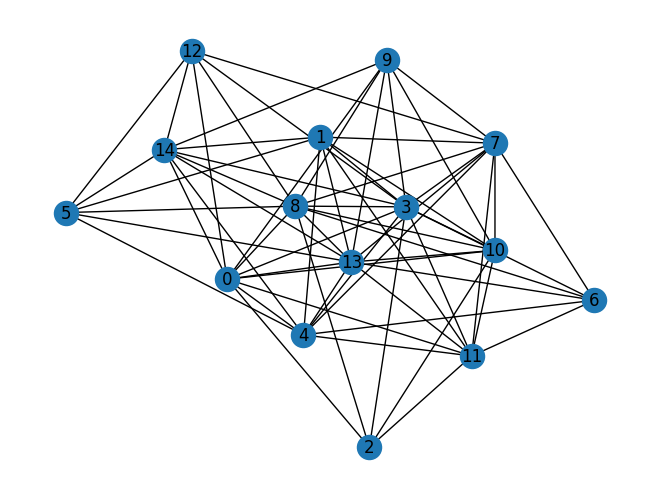

In [12]:
# Przykład grafu losowego na 15 wierzchołkach
import numpy as np
import networkx as nx

graph = nx.erdos_renyi_graph(n=15, p=0.6, seed=42)
nx.draw(graph, with_labels=True)

[(0, 3), (0, 10), (0, 14), (1, 4), (1, 11), (1, 13), (2, 8), (2, 11), (3, 6), (3, 7), (3, 10), (3, 14), (4, 11), (4, 13), (5, 14), (6, 7), (7, 10), (8, 9), (8, 12), (8, 13), (9, 13), (11, 13)]


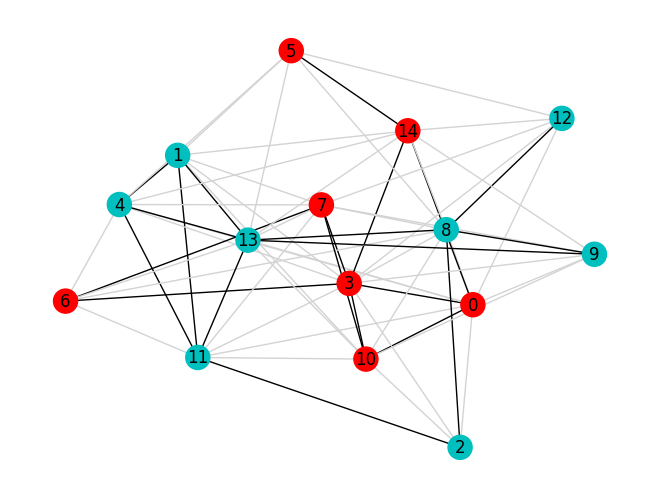

In [ ]:
# Rozwiązanie problemu
from collections import defaultdict
from math import inf
from itertools import product

Q = defaultdict(int)
for i, j in graph.edges:
    Q[(i,i)]+= -1
    Q[(j,j)]+= -1
    Q[(i,j)]+= 2

qubo = BinaryQuadraticModel(Q, "BINARY")
n = qubo.num_variables

best_energy = inf
best_state = []
for state in product([0, 1], repeat=n):
    x = np.array(state)
    energy = qubo.energy(x)
    if energy < best_energy:
        best_energy = energy
        best_state = state


# Interpretacja wyników
S0 = [node for node in graph.nodes if not best_state[node]]
S1 = [node for node in graph.nodes if best_state[node]]


uncut_edges = [(u, v) for u, v in graph.edges if best_state[u]==best_state[v]]

# narysowanie najlepszego znalezionego wyniku
nx.draw(graph, node_color=["r" if i in S0 else "c" for i in list(graph.nodes)], with_labels=True, 
       edge_color=["black" if e in uncut_edges else "lightgray" for e in list(graph.edges)])